## Module_3:

## Team Members:
* Isabel Vikesland
* Karinna Fink

## Project Title: 
### Spatial Distribution of Fibrosis in the Murine Bleomycin Model of Lung Fibrotic Disease



## Project Goal:
This project seeks to develop an image analysis pipeline to predict the extent of fibrosis in the lung at varying biopsy depths from the lung surface.

We will develop an algorithm to interpolate the degree of fibrosis at a specific depth based on a sample dataset. The goal is to enable Intuitive, a medical device company, to design a next-generation lung biopsy device that more effectively monitors the progression of lung fibrosis, particularly to evaluate how the growing prevalence of vaping among young people affects the pathogenesis of idiopathic pulmonary fibrosis at varying tissue depths.

In doing so, this project seeks to answer two key questions: *how does the extent of fibrosis vary throughout the depth of a fibrotic lung, and can interpolation be used to reliably predict the amount of fibrosis at a specific depth?*


## Disease Background: 
Idiopathic pulmonary fibrosis (IPF) is a serious chronic (long term) disease that affects the tissue surrounding the air sacs, or alveoli, in the lungs. This condition develops when that lung tissue becomes thick and stiff for unknown reasons. Over time, these changes can cause permanent scarring in the lungs, called fibrosis, that makes it progressively more difficult to breathe.

### Prevalence & incidence:

A 2023 systematic review and meta-analysis found that IPF has a *global incidence of 5.8 per 100,000 people* and a *prevalence of 17.7 per 100,000*, confirming it as a rare disease. However, rates vary significantly by region, with North America reporting notably higher figures, an incidence of 9.0 and prevalence of 27.2 per 100,000, compared to Europe and Asia, which we attribute to differences in study populations, diagnostic criteria, and environmental exposures.

### Risk factors (genetic, lifestyle):

IPF has a notable genetic component, with both familial and random cases sharing an underlying correlation of genetic risk. Studies have shown that as many as *20% of IPF cases cluster within families*, suggesting that inherited factors play a meaningful role in disease susceptibility. While environmental exposures also contribute, current evidence indicates that genetic predisposition and environmental triggers interact to produce the disease, meaning some individuals may be inherently more vulnerable to developing IPF than others.

*Smoking is the most well-established lifestyle risk factor for IPF* and is thought to contribute to disease progression through oxidative stress and lung tissue damage. *Vaping, while newer, is emerging as a similarly concerning exposure,* particularly among young adults. A case series of four young patients with 3–8 year e-cigarette histories found small airway-centered fibrosis and constrictive bronchiolitis on biopsy, with symptoms only partially reversing after cessation. This suggests that vaping may drive a distinct fibrotic disease pattern, raising concern that the growing prevalence of e-cigarette use could contribute to increased rates of pulmonary fibrosis in younger populations.

Additional environmental and occupational risk factors include exposure to metal dust (OR 1.83), wood dust (OR 1.62), and pesticides (OR 2.07), as well as farming or agricultural work (OR 1.88). These findings come from a 2021 systematic review and meta-analysis of case-control studies.

### Symptoms:

The most common symptoms of IPF are *shortness of breath and persistent cough*, though some patients may be asymptomatic in the early stages. nih Symptoms tend to worsen as the disease progresses and lung tissue becomes increasingly scarred and stiff. The rate of progression varies considerably between patients, in some, the disease remains stable for years, while in others it deteriorates rapidly. Many patients also experience acute exacerbations, during which symptoms suddenly become significantly more severe. In advanced stages, complications such as pulmonary hypertension and respiratory failure can develop as the lungs lose their ability to adequately oxygenate the blood.

### Standard of care treatment(s):

*There is currently no cure for IPF.* However, certain treatments may slow the progression of IPF and help your lungs work more efficiently, these treatments include: *oxygen therapy, medications such as nintedanib or pirfenidonem or a lung transplant.* Nintedanib and pirfenidonem are *antifibrotic drugs* that supresses the inflammatory signaling that causes fibrosis. Nintedanib targets specific molecular pathways, while pirfenidone has a broader, less targeted anti-inflammatory and antifibrotic effect. They are sometimes used together in clinical practice, as their mechanisms are complementary. 

### Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): 

IPF is driven by *repeated injury to the alveolar epithelium* in genetically and/or environmentally susceptible individuals, triggering abnormal repair responses and dysregulated signaling between epithelial cells and fibroblasts, leading to progressive scarring. A key feature is dysfunction of alveolar type II cells, which normally facilitate lung repair but in IPF become senescent and fail to regenerate tissue properly. The resulting scar tissue then creates a self-reinforcing feedback loop, with abnormal matrix stiffness further perpetuating fibrosis.

The stiffening of the lung walls caused by fibrosis reduces their elasticity, making it progressively harder to breathe and impairing the lung's ability to efficiently transfer oxygen into the bloodstream.


## Data-Set: 
This data set was recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab in the Division of Pulmonary and Critical Care at the University of Virginia.

The dataset was created using a bleomycin-induced lung injury mouse model to model IPF. Bleomycin, is an antibiotic that causes lung fibrosis as a side effect, was administered to mice and three weeks later the lungs were harvested for imaging.

The lungs were then fixed with paraformaldehyde, mounted in gel or wax, and sliced into transverse sections using a cryotome or microtome. Slicing in the transverse plane produces images at different depths through the lung, spanning from the top to the bottom of the tissue (0 to 10,000 μm (1 cm)), this is because the mouse lungs are oriented sideways compared to human lungs. Each slice was placed on a glass microscope slide and immunostained with fluorescent-labeled antibodies targeting three proteins of interest: desmin (marking myofibroblasts: the cells responsible for generating fibrotic scar tissue), smooth muscle alpha actin (marking large blood vessel smooth muscle cells), and CD-31 (marking endothelial cells in all blood vessels including capillaries).

The fluorescent images were then captured digitally under a microscope. For our project, the desmin signal was isolated and converted to black and white images, where the white pixels represent fibrotic lesions and black pixels represent healthy lung tissue. In total, 78 black and white images were collected at varying depths into the lung, these are the images we will use to create our image analysis

We chose 6 images to use as graphed data points for interpolation. We chose these data points because they came from images where the majority of the white pixels were due to fibrosis, not imaged blood vessels. We also chose the images to be at varying depths. The chosen image files and depths are listed below: 

images/MASK_SK658 Llobe ch010019.jpg,60

images/MASK_SK658 Llobe ch010168.jpg,6000

images/MASK_SK658 Slobe ch010096.jpg,9400

images/MASK_SK658 Slobe ch010098.jpg,10000

images/MASK_SK658 Slobe ch010111.jpg,8600

images/MASK_SK658 Slobe ch010140.jpg,8300

Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 


## Data Analyis: 



### Step 1: Initializing and importing

In [8]:
import cv2
import numpy as np
import pandas as pd
from termcolor import colored
import time
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd


graphed_files = [
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010019.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010168.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010096.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010098.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010111.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010140.jpg"
]
graphed_depths = [60, 6000, 3000, 9400, 10000, 8300]


### Step 2: Write and run a function that finds the percentage of the image taken up by white pixels ###

In [9]:
def get_white_pixels(csv_path, graphed_files): # two parameters: path to the csv file to be loaded into a dataframe and the files that you want actually graphed
    df = pd.read_csv(csv_path) # Read the csv file as a pandas dataframe
    results = []
    white_percents = []
    depths = []
    graphed_white_percents = []
    for i, row in df.iterrows():
        # Put the file path together
        file_beginning = "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/"
        filename = file_beginning + row['Filenames']

        # add the image depth form the datafram into a list
        depth = row['Depth from lung surface (in micrometers) where image was acquired']
        depths.append(depth)

        # Load grayscale image
        img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

        binary = img >= 127 # if the pixel value is at least 127, it is given the value of True (white) 

        # calculate the percentage of white pixels in the image
        white = np.sum(binary) # add how many values are true
        black = binary.size - white
        white_percent = 100 * white / (white + black)
        white_percents.append(white_percent)

        # for the files that are being graphed, add the percentage of white pixels to a list to be used for graphing
        if filename in graphed_files:
            graphed_white_percents.append(white_percent)
            #print(filename)

        results.append({"Filename": filename, "Depth": depth,"White Percent": white_percent})

        df2 = pd.DataFrame(results)
        df2.to_csv("Percent_White_Pixels.csv", index=False)

    print("The .csv file 'Percent_White_Pixels.csv' has been created.")
    return graphed_white_percents, depths, results, white_percents

graphed_white_percents, known_depths, results, white_percents = get_white_pixels('C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/Filenames and Depths for Students.csv', graphed_files)

The .csv file 'Percent_White_Pixels.csv' has been created.



### Step 3: Ask user how many points they would like to interpolate, and then ask the user what those points are

In [10]:
# ask user how many depths they would like to interpolate a point for 
number_depths = int(input(colored("Enter the number of depths at which you want to interpolate a point: ")))

interpolate_depths = []
counter = 0

while counter < number_depths: # iterates until the user has entered the number of depths they wanted to interpolate a point for

    depths_addition = float(input(colored("Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))
    if (depths_addition > min(graphed_depths)) and (depths_addition < max(graphed_depths)): # checks that entered depth is within the range of known depths
        interpolate_depths.append(depths_addition) # add the depth to the list of depths to be interpolated
        counter += 1

    else:
        print(colored("Please enter a depth between 60 and 10000 microns.", 'red')) # ask user to re-enter a depth if it is outside the range of known depths

### Step 4: Interpolate white percentage

In [11]:
x = graphed_depths
y = graphed_white_percents

#print(f"x: {x}")
#print(f"y: {y}")

# make copies of the known depths and white percentages to be used for interpolation
depths_i1 = graphed_depths[:]
white_percents_i1 = graphed_white_percents[:]
depths_i2 = graphed_depths[:]
white_percents_i2 = graphed_white_percents[:]

# linear interpolation
for i in range(number_depths):
    i1 = interp1d(x, y, kind = 'linear')
    interpolate_point1 = i1(interpolate_depths[i])
    depths_i1.append(interpolate_depths[i])
    white_percents_i1.append(interpolate_point1)

# quadratic interpolation
for i in range(number_depths):
    i2 = interp1d(x, y, kind = 'quadratic')
    interpolate_point2 = i2(interpolate_depths[i])
    depths_i2.append(interpolate_depths[i])
    white_percents_i2.append(interpolate_point2)


print("Linearly interpolated points: ")
for i in range(number_depths):
    print(f"Point {i+1}: ({depths_i1[-(i+1)]}, {white_percents_i1[-(i+1)]})")

print("Quadratically interpolated points: ")
for i in range(number_depths):
    print(f"Point {i+1}: ({depths_i2[-(i+1)]}, {white_percents_i2[-(i+1)]})")

Linearly interpolated points: 
Point 1: (8781.0, 6.714537728916515)
Point 2: (6549.0, 3.9856518973474917)
Point 3: (327.0, 0.981888552101291)
Quadratically interpolated points: 
Point 1: (8781.0, 6.700871672258953)
Point 2: (6549.0, 4.29520677596929)
Point 3: (327.0, 1.300585895123742)


### Step 5: Graph Results

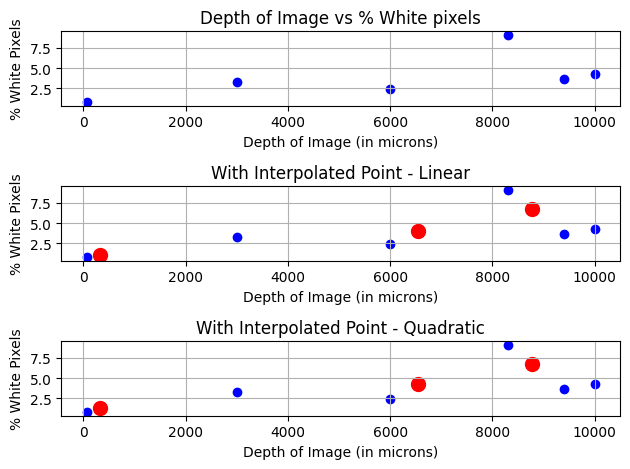

In [12]:
fig, axs = plt.subplots(3, 1) # make 3 plots

# plot without interpolated points
axs[0].scatter(graphed_depths, graphed_white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Depth of Image vs % White pixels')
axs[0].set_xlabel('Depth of Image (in microns)')
axs[0].set_ylabel('% White Pixels')
axs[0].grid(True)

# plot with linearly interpolated points
axs[1].scatter(depths_i1, white_percents_i1, marker='o',linestyle='-', color='blue')
axs[1].set_title('With Interpolated Point - Linear')
axs[1].set_xlabel('Depth of Image (in microns)')
axs[1].set_ylabel('% White Pixels')
axs[1].grid(True)

for i in range(number_depths):
    axs[1].scatter(depths_i1[len(depths_i2)-(i+1)], white_percents_i1[len(white_percents_i2)-(i+1)], color='red', s=100, label='Highlighted point')

# plot for quadratically interpolated points
axs[2].scatter(depths_i2, white_percents_i2, marker='o',linestyle='-', color='blue')
axs[2].set_title('With Interpolated Point - Quadratic')
axs[2].set_xlabel('Depth of Image (in microns)')
axs[2].set_ylabel('% White Pixels')
axs[2].grid(True)

for i in range(number_depths):
    axs[2].scatter(depths_i2[len(depths_i1)-(i+1)], white_percents_i2[len(white_percents_i1)-(i+1)], color='red', s=100, label='Highlighted point')

plt.tight_layout()
plt.show()

The top graph shows the 6 known points that were used for the interpolation. The second graph shows the linearly interpolated white pixel percentages for the 3 depths given by the user. The third graph shows those same points using quadratic interpolation. 

### Step 6: Calculate differences between interpolation and known points

In [13]:
def find_closest_point(depths, white_percentages):
    new_depth = depths[-number_depths:]
    best_differences = []
    best_depths = []
    indices = []
    counter = 0

    # for each interpolated depth, find the closest known depth and calculate the difference in white pixel percentage between the interpolated point and the closest known point
    for depth in new_depth:
        difference = 1000000 # set depth to something way higher than it could possibly be
        best_depth = 0
        index = 0

        # import the csv file as a dataframe and iterate through the rows to find the closest known depth to the interpolated depth
        df = pd.read_csv('C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/Filenames and Depths for Students.csv')
        for i, row in df.iterrows(): #iterate over rows in the dataframe
            new_diff = abs(depth - row['Depth from lung surface (in micrometers) where image was acquired'])

            if new_diff < difference: # iterate through row to find the closest known depth to the interpolated depth
                difference = new_diff
                best_depth = row['Depth from lung surface (in micrometers) where image was acquired']
                index = i
        best_differences.append(difference)
        best_depths.append(best_depth)
        indices.append(index)
        
        subtraction = abs(white_percentages[-(counter + 1)] - white_percents[index])
        print(f"At depth {depth}, the interpolated white pixel percentage is {white_percentages[-(counter+1)]}. The closest known depth is {best_depth}, which is {difference} micrometers away. At that point, the percentage of white pixels is {white_percents[index]}%, which is {subtraction}% away from the interpolated value")
        counter += 1

    
    return best_depths, indices


print("\n For Linear Interpolation: ")
find_closest_point(depths_i1,white_percents_i1)
print("\n For Quadratic Interpolation: ")
find_closest_point(depths_i2,white_percents_i2)



 For Linear Interpolation: 
At depth 327.0, the interpolated white pixel percentage is 6.714537728916515. The closest known depth is 330, which is 3.0 micrometers away. At that point, the percentage of white pixels is 0.9076118469238281%, which is 5.8069258819926866% away from the interpolated value
At depth 6549.0, the interpolated white pixel percentage is 3.9856518973474917. The closest known depth is 6600, which is 51.0 micrometers away. At that point, the percentage of white pixels is 2.4147748947143555%, which is 1.5708770026331362% away from the interpolated value
At depth 8781.0, the interpolated white pixel percentage is 0.981888552101291. The closest known depth is 8800, which is 19.0 micrometers away. At that point, the percentage of white pixels is 3.6032676696777344%, which is 2.6213791175764434% away from the interpolated value

 For Quadratic Interpolation: 
At depth 327.0, the interpolated white pixel percentage is 6.700871672258953. The closest known depth is 330, whi

([330, 6600, 8800], [9, 43, 62])

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
Fibrosis Increases with Lung Depth​

Fibrotic lesions occur predominantly at greater depths, consistent with
IPF's known alveolar involvement​

Biopsy devices should prioritize deeper tissue sampling​

Linear and quadratic interpolation models both fit the training data well,
with curve fit errors below 8%


A depth-informed biopsy device could improve diagnostic accuracy, but raises several ethical concerns:
•       Patients and doctors: Intended patients are minors who vape, informed consent and parental involvement are necessary, and doctors must not rely solely upon device predictions over clinical judgment.
•       Hospitals and health systems: Adopting this technology would require much more rigorous clinical validation before use.
•       Health insurance agencies: Access must be equitable, this tool should not only be available to those with premium coverage.
•       Public health policy: If this pipeline helps establish a link between vaping and lung fibrosis in young people, it should inform stricter e-cigarette regulation.

## Limitations and Future Work: 
The bleomycin-induced mouse model is a widely used method for studying IPF and reliably produces lesions with some histological similarities to human IPF. However, it is not a perfect representation of the disease. In humans, IPF develops slowly over years through repeated cycles of injury and aberrant repair, whereas bleomycin-induced fibrosis in mice is acute and inflammation-driven, failing to capture the chronic, self-sustaining nature of human IPF. Further more, histology procedures are different between species so artifacts signaling as fibrosis in mouse tissue might not show up in human tissue. 

Translating findings from animal to human models is always challenging, and a valuable future direction would be conducting a side-by-side image analysis comparing human IPF and bleomycin-induced mouse lung tissue to better characterize the similarities and differences between the two models. Future work should also focus on expanding the dataset to include more depth intervals and incorporating additional variables in the collection and classification of fibrotic tissue to more comprehensively capture fibrosis severity, whether that means cutting thinner tissue slices, exploring sections of the coronal or sagittal planes, or staining for additional markers of pre-fibrotic signaling.


## References:
AI Statement: All words are our own. Copilot was used to generate an efficient method of calculating white pixel percentages. That code was then edited to work with more data points. AI was also used to help with debugging, but all other code was written by the team. 

Dataset: Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine.

Association, American Lung. “Idiopathic Pulmonary Fibrosis (IPF).” Accessed April 1, 2026. https://www.lung.org/lung-health-diseases/lung-disease-lookup/idiopathic-pulmonary-fibrosis.

“E-Cigarette Use, Small Airway Fibrosis, and Constrictive Bronchiolitis.” NEJM Evidence, n.d. Accessed April 1, 2026. https://evidence.nejm.org/doi/full/10.1056/EVIDoa2100051.

Golchin, Negar, Aditya Patel, Julia Scheuring, et al. “Incidence and Prevalence of Idiopathic Pulmonary Fibrosis: A Systematic Literature Review and Meta-Analysis.” BMC Pulmonary Medicine 25 (August 2025): 378. https://doi.org/10.1186/s12890-025-03836-1.

Kropski, Jonathan A., Timothy S. Blackwell, and James E. Loyd. “The Genetic Basis of Idiopathic Pulmonary Fibrosis.” European Respiratory Journal 45, no. 6 (2015): 1717–27. https://doi.org/10.1183/09031936.00163814.

Kropski, Jonathan A., Timothy S. Blackwell, and James E. Loyd. “The Genetic Basis of Idiopathic Pulmonary Fibrosis.” Back to Basics. European Respiratory Journal 45, no. 6 (2015): 1717–27. https://doi.org/10.1183/09031936.00163814.

Mayo Clinic. “Nintedanib (Oral Route) - Side Effects & Dosage.” Accessed April 1, 2026. https://www.mayoclinic.org/drugs-supplements/nintedanib-oral-route/description/drg-20122674.

Mei, Qianru, Zhe Liu, He Zuo, Zhenhua Yang, and Jing Qu. “Idiopathic Pulmonary Fibrosis: An Update on Pathogenesis.” Frontiers in Pharmacology 12 (January 2022). https://doi.org/10.3389/fphar.2021.797292.

Oh, Chad K., Lynne A. Murray, and Nestor A. Molfino. “Smoking and Idiopathic Pulmonary Fibrosis.” Pulmonary Medicine 2012 (2012): 808260. https://doi.org/10.1155/2012/808260.

Park, Yeonkyung, Chiwon Ahn, and Tae-Hyung Kim. “Occupational and Environmental Risk Factors of Idiopathic Pulmonary Fibrosis: A Systematic Review and Meta-Analyses.” Scientific Reports 11, no. 1 (2021): 4318. https://doi.org/10.1038/s41598-021-81591-z.

“Pulmonary Fibrosis - What Is Idiopathic Pulmonary Fibrosis? | NHLBI, NIH.” June 26, 2023. https://www.nhlbi.nih.gov/health/idiopathic-pulmonary-fibrosis.

Spagnolo, Paolo, Jonathan A. Kropski, Mark G. Jones, et al. “Idiopathic Pulmonary Fibrosis: Disease Mechanisms and Drug Development.” Pharmacology & Therapeutics 222 (June 2021): 107798. https://doi.org/10.1016/j.pharmthera.2020.107798.
